In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("Fake.csv")

In [3]:
print(df.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


In [4]:
print(df.tail())

                                                   title  \
23476  McPain: John McCain Furious That Iran Treated ...   
23477  JUSTICE? Yahoo Settles E-mail Privacy Class-ac...   
23478  Sunnistan: US and Allied ‘Safe Zone’ Plan to T...   
23479  How to Blow $700 Million: Al Jazeera America F...   
23480  10 U.S. Navy Sailors Held by Iranian Military ...   

                                                    text      subject  \
23476  21st Century Wire says As 21WIRE reported earl...  Middle-east   
23477  21st Century Wire says It s a familiar theme. ...  Middle-east   
23478  Patrick Henningsen  21st Century WireRemember ...  Middle-east   
23479  21st Century Wire says Al Jazeera America will...  Middle-east   
23480  21st Century Wire says As 21WIRE predicted in ...  Middle-east   

                   date  
23476  January 16, 2016  
23477  January 16, 2016  
23478  January 15, 2016  
23479  January 14, 2016  
23480  January 12, 2016  


In [5]:
#number of rows and columns
print(df.shape)

(23481, 4)


In [6]:
#to print name of columns
print(df.columns)

Index(['title', 'text', 'subject', 'date'], dtype='object')


In [7]:
#for the information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
None


In [8]:
#statistical summary
print(df.describe())

                                                    title   text subject  \
count                                               23481  23481   23481   
unique                                              17903  17455       6   
top     MEDIA IGNORES Time That Bill Clinton FIRED His...           News   
freq                                                    6    626    9050   

                date  
count          23481  
unique          1681  
top     May 10, 2017  
freq              46  


In [9]:
#missing values
print(df.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64


In [10]:
#to check the duplicate values
print(df.duplicated().sum())

3


In [11]:
#dropping the duplicate values
df = df.drop_duplicates()

In [12]:
df["title"].value_counts()

title
MEDIA IGNORES Time That Bill Clinton FIRED His FBI Director On Day Before Vince Foster Was Found Dead    6
FORMER FBI ASST DIRECTOR: “Jim Comey ‘Danced With The Devil’…I’m Glad He’s Gone” [VIDEO]                 4
ELEMENTARY SCHOOL PLANS ‘BLACKS ONLY’ FIELD TRIP TO COLLEGE FOR THIRD GRADERS                            4
NOT GRASSROOTS: #Ferguson Protestors PAID Over $5K To Attack Police, Instigate Violence And Disrupt      3
STAND UP AND CHEER! UKIP Party Leader SLAMS Germany, France And EU Invasion Of Phony Refugees [VIDEO]    3
                                                                                                        ..
 Iowa Legislator Leaves Republican Party Over Trump’s Racism                                             1
 Mark Kirk Becomes First Republican To Un-Endorse Donald Trump (VIDEO)                                   1
 Women Will Get More Elected Representation If Clinton Becomes President                                 1
 Meryl Streep Impersonated Dona

In [13]:
df["subject"].value_counts()

subject
News               9050
politics           6838
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

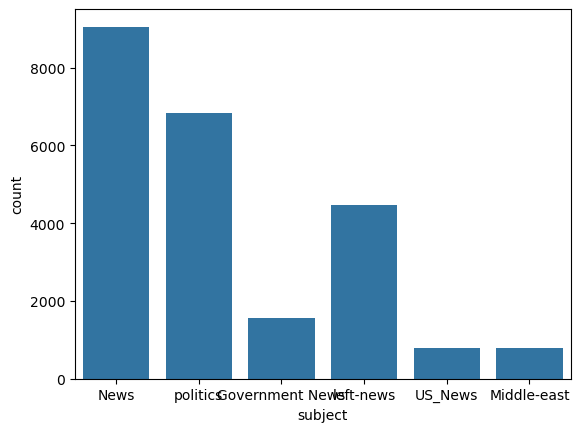

In [14]:
sns.countplot(x = "subject", data=df)
plt.show

In [15]:
#create article length
df["Word Count"] = df["text"].apply(lambda x: len(str(x).split()))

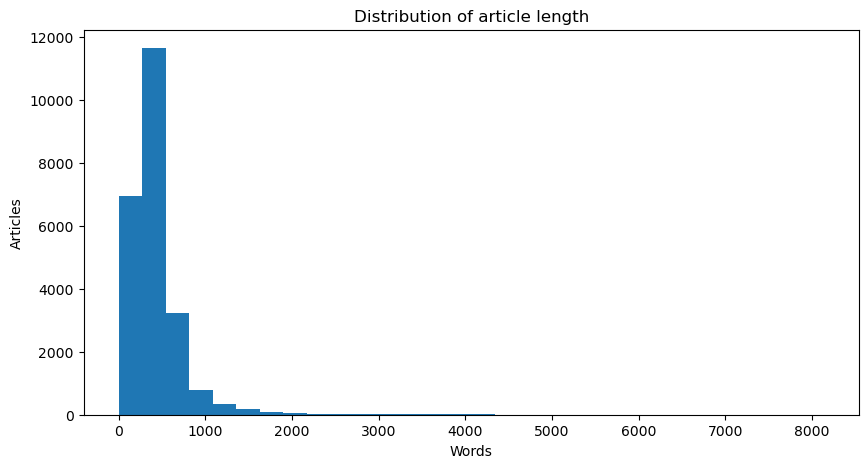

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(df["Word Count"], bins=30)
plt.xlabel("Words")
plt.ylabel("Articles")
plt.title("Distribution of article length")
plt.show()

In [17]:
print(df.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  Word Count  
0  December 31, 2017         495  
1  December 31, 2017         305  
2  December 30, 2017         580  
3  December 29, 2017         444  
4  December 25, 2017         420  


In [18]:
print(df.columns)

Index(['title', 'text', 'subject', 'date', 'Word Count'], dtype='object')


In [19]:
print(df["text"].head())

0    Donald Trump just couldn t wish all Americans ...
1    House Intelligence Committee Chairman Devin Nu...
2    On Friday, it was revealed that former Milwauk...
3    On Christmas day, Donald Trump announced that ...
4    Pope Francis used his annual Christmas Day mes...
Name: text, dtype: object


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [21]:
import pandas as pd
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [22]:
# Merge both datasets
fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], ignore_index=True)

In [23]:
#Shuffle the whole dataset
df = df.sample(frac=1, random_state=42).reset_index(drop = True)

In [24]:
print(df.head())
print(df["label"].value_counts())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  
label
0    23481
1    21417
Name: count, dtype: in

In [25]:
print(df.shape)

(44898, 5)


In [26]:
#Text preprocessing
df["text"] = df["text"].str.lower()

In [27]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [28]:
import string
def remove_punctuation(text):
    return str(text).translate(str.maketrans('', '', string.punctuation))

df["text"] = df["text"].apply(remove_punctuation)

In [29]:
import re
def remove_urls(text):
    if not isinstance(text, str):
        return text
    return re.sub(r'https?://\S+|www\.\S+', '', text)

df["text"] = df["text"].apply(remove_urls)

In [30]:
def remove_numbers(text):
    if not isinstance(text, str):
        return text
    return re.sub(r'\d+', '', text)

df["text"] = df["text"].apply(remove_numbers)


In [31]:
df["tokens"] = df["text"].apply(lambda x: str(x).split())

In [32]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(lambda words: [word for word in words if word not in stop_words])

[nltk_data] Downloading package punkt to C:\Users\Khushi
[nltk_data]     Verma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Khushi
[nltk_data]     Verma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
import ssl
import nltk
import nltk.stem 
from nltk.stem import WordNetLemmatizer

try: 
    _create_unverified_https_context = ssl._create_unverified_https_context
except AttributeError:
    pass
else: 
    ssl.create_default_https_context = _create_unverified_https_context

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw- 1.4')

lemmatizer = WordNetLemmatizer()
df["tokens"] = df["tokens"].apply(lambda words: [lemmatizer.lemmatize(word) for word in words])

[nltk_data] Downloading package punkt to C:\Users\Khushi
[nltk_data]     Verma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Khushi
[nltk_data]     Verma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Khushi
[nltk_data]     Verma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading omw- 1.4: Package 'omw- 1.4' not found in
[nltk_data]     index


In [34]:
df["clean_text"] = df["tokens"].apply(lambda words: " ".join(words))

In [35]:
print(df[["text", "clean_text"]].head())

                                                text  \
0  st century wire says ben stein reputable profe...   
1  washington reuters  us president donald trump ...   
2  reuters  puerto rico governor ricardo rossello...   
3  on monday donald trump once again embarrassed ...   
4  glasgow scotland reuters  most us presidential...   

                                          clean_text  
0  st century wire say ben stein reputable profes...  
1  washington reuters u president donald trump re...  
2  reuters puerto rico governor ricardo rossello ...  
3  monday donald trump embarrassed country accide...  
4  glasgow scotland reuters u presidential candid...  


In [36]:
print(df[["clean_text", "label"]].head())

                                          clean_text  label
0  st century wire say ben stein reputable profes...      0
1  washington reuters u president donald trump re...      1
2  reuters puerto rico governor ricardo rossello ...      1
3  monday donald trump embarrassed country accide...      0
4  glasgow scotland reuters u presidential candid...      1


In [37]:
x = df["clean_text"]
y = df["label"]

print(x.head())
print(y.head())

0    st century wire say ben stein reputable profes...
1    washington reuters u president donald trump re...
2    reuters puerto rico governor ricardo rossello ...
3    monday donald trump embarrassed country accide...
4    glasgow scotland reuters u presidential candid...
Name: clean_text, dtype: object
0    0
1    1
2    1
3    0
4    1
Name: label, dtype: int64


In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y, 
    test_size = 0.2, 
    random_state = 42)

print(x_train.shape)
print(x_test.shape)

(35918,)
(8980,)


In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features= 5000)
x_train_vector = vectorizer.fit_transform(x_train)
x_test_vector = vectorizer.transform(x_test)
print(x_train_vector.shape)

(35918, 5000)


In [40]:
#train logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train_vector, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
#MAKE PREDICTIONS
prediction = model.predict(x_test_vector)
print(prediction[:20])

[0 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 1]


In [42]:
print(prediction[:10])

[0 1 1 0 1 1 0 0 1 0]


In [43]:
print(df["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [44]:
print(y_train.value_counts())

label
0    18771
1    17147
Name: count, dtype: int64


In [45]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, prediction)
print(accuracy)

0.9856347438752784


In [46]:
print(df["clean_text"].iloc[0])

st century wire say ben stein reputable professor pepperdine university also hollywood fame appearing tv show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement th circuit court washington state coup tat executive branch constitution stein went call judge seattle political puppet judiciary political pawn watch interview complete statement note stark contrast rhetoric leftist medium pundit neglect note court ever blocked presidential order immigration past discus legal efficacy halt actual text executive orderread trump news st century wire trump filessupport work subscribing becoming member wiretv


In [47]:
print(x_train_vector.shape)
print(x_test_vector.shape)

(35918, 5000)
(8980, 5000)


In [48]:
print(len(vectorizer.vocabulary_))

5000


In [49]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
#The classification report evaluates the model using precision, Recall and F1-score. These metrics are specially useful for classification
#problems like fake news detection
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [51]:
#confusionn matrix
cm = confusion_matrix(y_test, prediction)
print(cm)

[[4627   83]
 [  46 4224]]


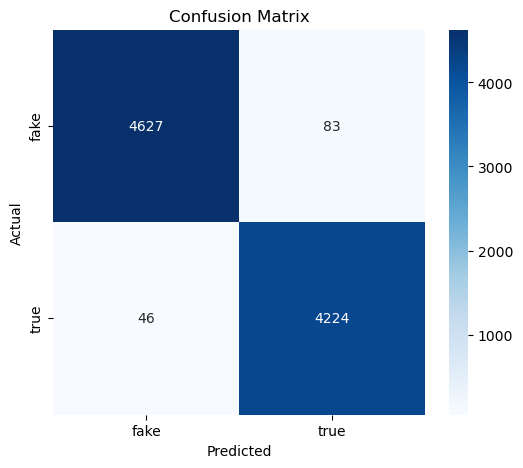

In [52]:
#visulaize the Confusion Matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = ["fake", "true"],
    yticklabels = ["fake", "true"],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [53]:
#create a prediction function
def predict_news(news):
    vector = vectorizer.transform([news])
    result = model.predict(vector)

    if result[0] == 0:
        return "Fake News"
    else:
        return "True News"

In [54]:
#Testing with a custom sentence
news1 = "NASA announces discovery of a new Earth-like planet."
print(predict_news(news1))

Fake News


In [55]:
news2 = "Aliens have taken over the White House"
print(predict_news(news2))

True News


In [56]:
news3 = "The stock market closed higher on friday."
print(predict_news(news3))

True News


In [57]:
#Saving the trained model
import joblib

In [58]:
joblib.dump(model, "Fake_news_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [59]:
import os
print(os.listdir())

['.git', 'dataset.ipynb', 'Fake.csv', 'Fake_news_model.pkl', 'README.md', 'tfidf_vectorizer.pkl', 'True.csv']


In [60]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, prediction)
print(cm)

[[4627   83]
 [  46 4224]]


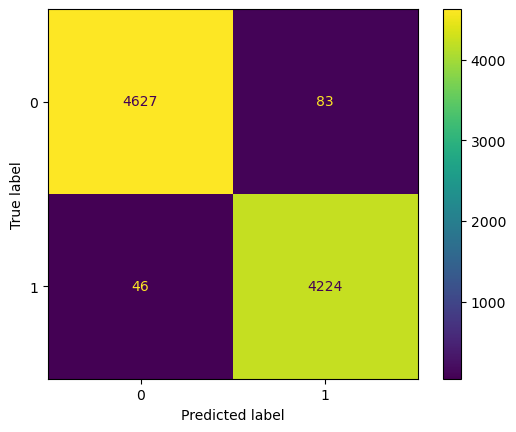

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

In [62]:
#Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [63]:
#Train naive byes
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(x_train_vector, y_train)
nb_prediction = nb.predict(x_test_vector)

In [64]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, nb_prediction))

0.9438752783964365


In [65]:
#Compare models
print("LogisticRegression: ", accuracy_score(y_test, prediction))
print("naive_bayes: ", accuracy_score(y_test, nb_prediction))

LogisticRegression:  0.9856347438752784
naive_bayes:  0.9438752783964365


In [66]:
import os
print(os.listdir())

['.git', 'dataset.ipynb', 'Fake.csv', 'Fake_news_model.pkl', 'README.md', 'tfidf_vectorizer.pkl', 'True.csv']


In [67]:
import joblib
loaded_model = joblib.load("Fake_news_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [68]:
#Test the loaded model
sample = "NASA discovers water on Mars."
# sample = clean_text(sample)
sample = loaded_vectorizer.transform([sample])
print(loaded_model.predict(sample))

[0]


In [69]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Khushi Verma\OneDrive\Desktop\Fake News Detection\AI-powered-fake-news-detection-using
['.git', 'dataset.ipynb', 'Fake.csv', 'Fake_news_model.pkl', 'README.md', 'tfidf_vectorizer.pkl', 'True.csv']


In [70]:
test_news = [
    "NASA discovers a new earth like planet.",
    "Aliens have taken over the White House. ",
    "The Indian Goverment has announced a new education policy.",
    "Scientists confirm humans can breathe underwater.",
    "The moon is made of chocolate.",
]
for news in test_news:
    prediction = predict_news(news)
    print(f"\nNews: {news}")
    print(f"Prediction: {prediction}")


News: NASA discovers a new earth like planet.
Prediction: Fake News

News: Aliens have taken over the White House. 
Prediction: True News

News: The Indian Goverment has announced a new education policy.
Prediction: True News

News: Scientists confirm humans can breathe underwater.
Prediction: Fake News

News: The moon is made of chocolate.
Prediction: True News


In [71]:
vector = vectorizer.transform([news[0]])
probability = model.predict_proba(vector)
print(probability)

[[0.90481554 0.09518446]]


In [72]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]',' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

In [73]:
print("Fake Probability : ", probability[0][0])
print("True Probability : ", probability[0][1])

Fake Probability :  0.904815539759425
True Probability :  0.09518446024057507


In [88]:
#prediction function with confidence
def predict_news_with_confidence(news):
    cleaned = clean_text(news)
    vector = vectorizer.transform([cleaned])
    single_prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)
    confidence = max(probability[0])*100
    if prediction == 0:
        result = "Fake News"
    else: 
        result = "True News"

    return result, confidence

In [89]:
# news = input("Enter News : ")
news = "Indian goverment has given 10 lakh new jobs this year."
result, confidence = predict_news_with_confidence(news)

print("Prediction : ", result)
print("Confidence : ", round(confidence, 2), "%")

Prediction :  True News
Confidence :  84.88 %


In [90]:
import time
start = time.time()
predict_news(news)
end = time.time()
print("Prediction Time : ", end-start, "seconds")

Prediction Time :  0.0018703937530517578 seconds


In [92]:
print(type(prediction))
print(prediction)

<class 'str'>
True News


In [93]:
prediction = model.predict(x_test_vector)
print(type(prediction))

<class 'numpy.ndarray'>


In [94]:
accuracy_score(y_test, prediction)

0.9856347438752784

In [95]:
print(type(y_test))
print(type(prediction))
print(len(y_test), len(prediction))

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
8980 8980


In [97]:
from sklearn.metrics import accuracy_score
model_scores = {
    "LogisticRegression": accuracy_score(y_test, prediction),
    "Naive Bayes": accuracy_score(y_test, nb_prediction)
}
for name, score in model_scores.items():
    print(f"{name}: {score*100: .2f}%")

LogisticRegression:  98.56%
Naive Bayes:  94.39%


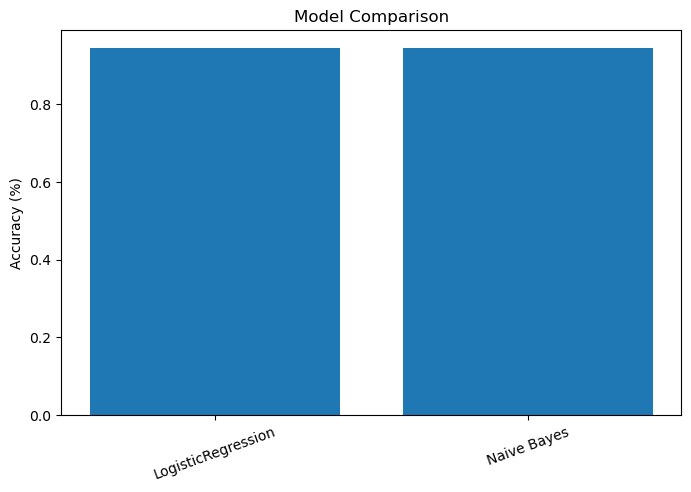

In [98]:
#graph
import matplotlib.pyplot as plt
names = list(model_scores.keys())
scores = [score*100 for score in model_scores.values()]
plt.figure(figsize=(8, 5))
plt.bar(names, score)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()